In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

Question 1: Firstly, replace all Missing values with relevant figures.

In [5]:
df = pd.read_csv('Dataset_Day7.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1


In [6]:
cols = ["Glucose", "BloodPressure", "BMI", "DiabetesPedigreeFunction"]
df[cols] = df[cols].replace(0, np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   BMI                       757 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 42.1 KB


In [7]:
#Treating missing data
numeric_col=[]

for col in df.columns:
    if df[col].dtype.name != 'object':
        numeric_col.append(col)

print(numeric_col)

median_value = df[numeric_col].median()
print(median_value)

df = df.fillna(median_value)
df.info()

['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
BMI                          32.3000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(3)
m

Question 2: Then remove all existing outliers and get the final data for classification.

In [8]:
for col in cols:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

# Outlier Detection using z-score
OutlierRows = df[
    (df["Glucose"] > 3) | (df["Glucose"] < -3) |
    (df["BloodPressure"] > 3) | (df["BloodPressure"] < -3) |
    (df["BMI"] > 3) | (df["BMI"] < -3) |
    (df["DiabetesPedigreeFunction"] > 3) | (df["DiabetesPedigreeFunction"] < -3)
]

print("% of Outlier rows in the dataset is " + str(len(OutlierRows) / len(df) * 100) + "\n")

data_OutlierFree = df.drop(OutlierRows.index, axis=0)

% of Outlier rows in the dataset is 2.734375



Question 3: Split the data into 70% training and 30% testing data. Then, use a k-Nearest Neighbor algorithm with target variable as ‘Outcome’. (Random_state = 203)

a.	Print the default model performance metrics: Accuracy, Precision, Recall, F1Score
b.	Plot a Precision & Recall vs k(no. of neighbours) curve (both Prec and Rec on the same graph). Find the k for which F1-score is the highest. Use any one Distance Metric for this problem.
c.	Find the best distance metric, no. of neighbors combination for the kNN algorithm.

In [9]:
# Data Splitting into 70% training and 30% testing data

X = data_OutlierFree.drop("Outcome",axis=1)
y = data_OutlierFree["Outcome"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=203)
len(X_test),len(X_train)

(225, 522)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import math

k_start = int(math.sqrt(len(X_train)))
print(k_start)

metric_start = 'euclidean'

knn = KNeighborsClassifier(n_neighbors = k_start, metric = metric_start)

#train the model
knn = knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Model performance metrics are obtained as below, for k_start = "+str(k_start)+" and distance metric = "+metric_start)

print("Accuracy is "+str(accuracy_score(y_test, y_pred)))
print("Precision is "+str(precision_score(y_test, y_pred)))
print("Recall is "+str(recall_score(y_test, y_pred)))
print("F1 Score is "+str(f1_score(y_test, y_pred)))

22
Model performance metrics are obtained as below, for k_start = 22 and distance metric = euclidean
Accuracy is 0.7066666666666667
Precision is 0.6666666666666666
Recall is 0.3902439024390244
F1 Score is 0.49230769230769234


C:\Users\archi\AppData\Local\Temp\ipykernel_21236\683374711.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  PerfData = pd.concat([PerfData, pd.DataFrame(row, columns=['Nearest Neighbor', 'Distance Metric', 'Precision', 'Recall', 'F1-Score'])], ignore_index=True)


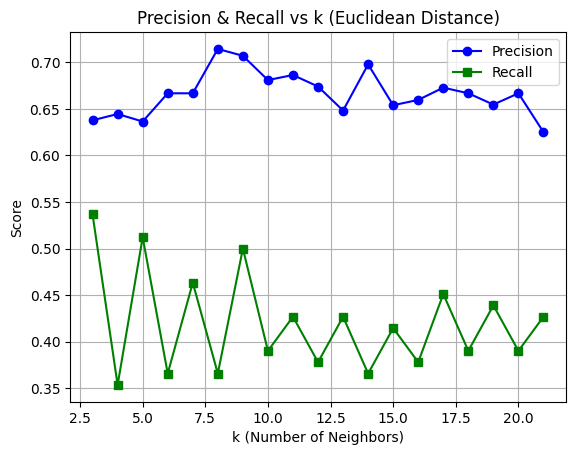


Best k based on F1-Score: 9 with F1-Score = 0.5857


In [12]:
k_values = np.arange(3, int(math.sqrt(len(X_train))), 1)
metric = 'euclidean'


PerfData = pd.DataFrame(columns=['Nearest Neighbor', 'Distance Metric', 'Precision', 'Recall', 'F1-Score'])

for k in k_values:
    
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    row = [[k, metric, 
            precision_score(y_test, y_pred), 
            recall_score(y_test, y_pred), 
            f1_score(y_test, y_pred)]]

    PerfData = pd.concat([PerfData, pd.DataFrame(row, columns=['Nearest Neighbor', 'Distance Metric', 'Precision', 'Recall', 'F1-Score'])], ignore_index=True)

euclidean_data = PerfData[PerfData['Distance Metric'] == 'euclidean']

plt.plot(euclidean_data['Nearest Neighbor'], euclidean_data['Precision'], 'b-o', label='Precision')
plt.plot(euclidean_data['Nearest Neighbor'], euclidean_data['Recall'], 'g-s', label='Recall')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Score')
plt.title('Precision & Recall vs k (Euclidean Distance)')
plt.legend()
plt.grid(True)
plt.show()

best_index = euclidean_data['F1-Score'].idxmax()
best_k = int(euclidean_data.loc[best_index, 'Nearest Neighbor'])
best_f1 = euclidean_data.loc[best_index, 'F1-Score']

print(f"\nBest k based on F1-Score: {best_k} with F1-Score = {best_f1:.4f}")

Observations:

At k = 9, precision and recall is balanced
Recall fluctuates heavily between 0.35 and 0.55, this indicates inconsistency
Recall is much lower than precision values, which means the model will make more negative predictions
As k increases, precision improves but recall decreases
Precision is more stable, i.e., has smaller fluctuations, than recall across values of k

In [14]:
#Find the best distance metric, no. of neighbors combination for the kNN algorithm.
k_values = np.arange(3, int(math.sqrt(len(X_train))), 1)
metric_values = ['euclidean','manhattan','cosine','hamming']

PerfData = pd.DataFrame(columns = ['Nearest Neighbor', 'Distance Metric', 'Precision', 'Recall', 'F1-Score'])

for dm in metric_values:
    for k in k_values:

        print(str(k)+" "+dm)
        knn = KNeighborsClassifier(n_neighbors = k, metric = dm)
        knn = knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)

        rows = [[k, dm, precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)]]
        PerfData = pd.concat([PerfData, pd.DataFrame(rows, columns=['Nearest Neighbor', 'Distance Metric', 'Precision', 'Recall', 'F1-Score'])], ignore_index=True)

display(PerfData.head())

3 euclidean
4 euclidean
5 euclidean
6 euclidean
7 euclidean
8 euclidean
9 euclidean
10 euclidean
11 euclidean
12 euclidean
13 euclidean
14 euclidean


C:\Users\archi\AppData\Local\Temp\ipykernel_21236\1043096828.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  PerfData = pd.concat([PerfData, pd.DataFrame(rows, columns=['Nearest Neighbor', 'Distance Metric', 'Precision', 'Recall', 'F1-Score'])], ignore_index=True)


15 euclidean
16 euclidean
17 euclidean
18 euclidean
19 euclidean
20 euclidean
21 euclidean
3 manhattan
4 manhattan
5 manhattan
6 manhattan
7 manhattan
8 manhattan
9 manhattan
10 manhattan
11 manhattan
12 manhattan
13 manhattan
14 manhattan
15 manhattan
16 manhattan
17 manhattan
18 manhattan
19 manhattan
20 manhattan
21 manhattan
3 cosine
4 cosine
5 cosine
6 cosine
7 cosine
8 cosine
9 cosine
10 cosine
11 cosine
12 cosine
13 cosine
14 cosine
15 cosine
16 cosine
17 cosine
18 cosine
19 cosine
20 cosine
21 cosine
3 hamming
4 hamming
5 hamming
6 hamming
7 hamming
8 hamming
9 hamming
10 hamming
11 hamming
12 hamming
13 hamming
14 hamming
15 hamming
16 hamming
17 hamming
18 hamming
19 hamming
20 hamming
21 hamming


,Nearest Neighbor,Distance Metric,Precision,Recall,F1-Score
0,3,euclidean,0.637681,0.536585,0.582781
1,4,euclidean,0.644444,0.353659,0.456693
2,5,euclidean,0.636364,0.512195,0.567568
3,6,euclidean,0.666667,0.365854,0.472441
4,7,euclidean,0.666667,0.463415,0.546763


In [15]:
PerfData[PerfData['F1-Score'] == max(PerfData['F1-Score'])]

,Nearest Neighbor,Distance Metric,Precision,Recall,F1-Score
50,15,cosine,0.728814,0.52439,0.609929


In [16]:
best_idx = PerfData['F1-Score'].idxmax()
best_row = PerfData.loc[best_idx]

print(f"Best k: {int(best_row['Nearest Neighbor'])}")
print(f"Best Distance Metric: {best_row['Distance Metric']}")
print(f"Best F1-Score: {best_row['F1-Score']:.4f}")

Best k: 15
Best Distance Metric: cosine
Best F1-Score: 0.6099
